# Question B3 (10 marks)

> Besides ensuring that your neural network performs well, it is important to be able to explain the model’s decision. **Captum** is a very handy library that helps you to do so for PyTorch models.

> Many model explainability algorithms for deep learning models are available in Captum. These algorithms are often used to generate an attribution score for each feature. Features with larger scores are more ‘important’ and some algorithms also provide information about directionality (i.e. a feature with very negative attribution scores means the larger the value of that feature, the lower the value of the output).

> In general, these algorithms can be grouped into two paradigms:
> - **perturbation based approaches** (e.g. Feature Ablation)
> - **gradient / backpropagation based approaches** (e.g. Saliency)

> The former adopts a brute-force approach of removing / permuting features one by one and does not scale up well. The latter depends on gradients and they can be computed relatively quickly. But unlike how backpropagation computes gradients with respect to weights, gradients here are computed **with respect to the input**. This gives us a sense of how much a change in the input affects the model’s outputs.



In [1]:
SEED = 42

import os

import random
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd

import torch
import torch.nn as nn

from captum.attr import Saliency, DeepLift, IntegratedGradients, GradientShap, FeatureAblation

---

## 1. Data Preprocessing

> First, load the dataset following the splits in Question B1. To keep things simple, we will **limit our analysis to numeric / continuous features only**. Drop all categorical features from the dataframes. Do not standardise the numerical features for now.



In [2]:
df = pd.read_csv('hdb_price_prediction.csv')

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
df = df.drop(columns=categorical_cols)

print("Dropped categorical features:", categorical_cols)
print("Remaining shape:", df.shape)

df.head()

Dropped categorical features: ['town', 'full_address', 'nearest_stn', 'flat_model_type', 'storey_range']
Remaining shape: (159553, 9)


,month,year,dist_to_nearest_stn,dist_to_dhoby,degree_centrality,eigenvector_centrality,remaining_lease_years,floor_area_sqm,resale_price
0,1,2017,1.007264,7.006044,0.016807,0.006243,61.333333,44.0,232000.0
1,1,2017,1.271389,7.983837,0.016807,0.006243,60.583333,67.0,250000.0
2,1,2017,1.069743,9.090700,0.016807,0.002459,62.416667,67.0,262000.0
3,1,2017,0.946890,7.519889,0.016807,0.006243,62.083333,68.0,265000.0
4,1,2017,1.092551,9.130489,0.016807,0.002459,62.416667,67.0,265000.0


In [3]:
train   = df[df["year"] <= 2019].copy()
val     = df[df["year"] == 2020].copy()
test    = df[df["year"] == 2021].copy()

In [4]:
print (f"Training Data Shape: {train.shape}")
print (f"Validation Data Shape: {val.shape}")
print (f"Test Data Shape: {test.shape}")

Training Data Shape: (64057, 9)
Validation Data Shape: (23313, 9)
Test Data Shape: (29057, 9)


---

## 2. Model Explainability via `Captum`

### 2.1 Model

> Follow this tutorial to generate the plot from various model explainability algorithms (https://captum.ai/tutorials/House_Prices_Regression_Interpret).
Specifically, make the following changes:
> - Use a feedforward neural network with 3 hidden layers, each having 5 neurons. Train using Adam optimiser with learning rate of 0.0005.
> - Use Saliency, DeepLift, Integrated Gradients, GradientSHAP, Feature Ablation


We can use a standard `PyTorch` model (like in Part A where we inherit `torch.nn.Module`), a `PyTorch Tabular` model (like in Part B1), or a `PyTorch WideDeep` model (like Part B2)

Standard `PyTorch` model is low-level, so everything has to be done maunally. `PyTorch Tabular` and `PyTorch WideDeep` models are high-level that automates the boring stuff like categorical encoding and gives pre-built, state-of-the-art neurnal networks.

`PyTorch Tabular` is for tabular data only, while `PyTorch WideDeep` accepts image and text data on top of tabular data (i.e. multimodal).

For this question, since we are doing the same data split as B1, we will just use the same model from B1 (`PyTorch Tabular`)

In [5]:
torch.manual_seed(SEED)

target_col = "resale_price"
feature_cols = [col for col in df.columns if col != target_col]

print(target_col)
print(feature_cols)

resale_price
['month', 'year', 'dist_to_nearest_stn', 'dist_to_dhoby', 'degree_centrality', 'eigenvector_centrality', 'remaining_lease_years', 'floor_area_sqm']


In [6]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import CategoryEmbeddingModelConfig
from pytorch_tabular.config import (
    DataConfig,
    OptimizerConfig,
    TrainerConfig,
)

data_config = DataConfig(
    target                          = [target_col],  # target column name
    continuous_cols                 = feature_cols,   # list of continuous column names to use
) 

trainer_config = TrainerConfig(
    batch_size      = 1024,
    max_epochs      = 50,
    seed            = SEED,
)

# Define the Model Architecture
model_config = CategoryEmbeddingModelConfig(
    task        = "regression",
    layers      = "5-5-5",     # 3 hidden layer with 5 neurons each
    activation  = "ReLU",
    learning_rate=0.0005
)

optimizer_config = OptimizerConfig(
    optimizer="Adam",
)

tabular_model = TabularModel(
    data_config         = data_config       ,
    model_config        = model_config      ,
    optimizer_config    = optimizer_config  ,
    trainer_config      = trainer_config,
)

2026-03-05 23:33:31,496 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off


In [7]:
import torch

# Capture the original function
_orig_torch_load = torch.load

# Define a version that always sets weights_only to False
def _trusted_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _orig_torch_load(*args, **kwargs)

# Overwrite the global torch.load
torch.load = _trusted_load

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler

# Define your scaler
target_scaler = StandardScaler()

# Train the model using train/validation split
tabular_model.fit(
    train           =train, 
    validation      =val,
    target_transform=target_scaler
)

# Predict on test set
test_predictions = tabular_model.predict(test)

test_predictions.head()

Seed set to 42
2026-03-05 23:33:36,146 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-03-05 23:33:36,149 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.77004694 -1.77004694 -1.77004694 ...  1.5995962   1.5995962
  1.5995962 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.fit_transform(
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.26348636 -1.26348636 -1.26348636 ...  1.19326285  1.19326285
  1.1

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ CategoryEmbeddingBackbone │    105 │ train │     0 │
│ 1 │ _embedding_layer │ Embedding1dLayer          │     16 │ train │     0 │
│ 2 │ head             │ LinearHead                │      6 │ train │     0 │
│ 3 │ loss             │ MSELoss                   │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 127                                                                                              
Non-trainable params: 0                                                                                            
Total params: 127                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: 
UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

2026-03-05 23:34:28,454 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-03-05 23:34:28,454 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.77004694 -1.77004694 -1.77004694 ...  1.5995962   1.5995962
  1.5995962 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.transform(data.loc[:, self.config.continuous_cols])
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3.65001206 3.65001206 3.65001206 ... 3.65001206 3.65001206 3.65001206]'

,resale_price_prediction
87370,229995.265625
87371,229995.265625
87372,271228.656250
87373,265759.781250
87374,265370.093750


In [9]:
# Get prediction column (usually "resale_price_prediction")
predicted_cols = [col for col in test_predictions.columns if col.endswith("_prediction")]
predicted_col = predicted_cols[0]  # one target column

y_true = test[target_col].to_numpy()
y_pred = test_predictions[predicted_col].to_numpy()

# Metrics
test_mse = mean_squared_error(y_true, y_pred)
test_r2 = r2_score(y_true, y_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test R2 : {test_r2:.4f}")

Test MSE: 8998225663.8050
Test R2 : 0.6598


### 2.2. Model Explainability

We are to use the following 5 algorithms...

- **Saliency**  
It calculates the gradient (the derivative) of the output with respect to the input features. Think of it as asking the model: "If I tweak this specific feature just a tiny bit right now, how drastically does the predicted price change?"

- **Integrated Gradients (IG)**  
Saliency has a flaw called "saturation" (where a feature is important, but tweaking it further doesn't change the output, so the gradient becomes zero). IG solves this by calculating gradients along a straight path from a "baseline" (usually a tensor of all zeros) to the actual input data, and then integrating them.

- **DeepLift** 
Instead of gradients, DeepLift compares the activation of every single neuron in your network to a "reference" (baseline) activation. It traces the difference between the actual activation and the reference activation backward through the network to assign contribution scores to the inputs. It is generally faster than Integrated Gradients.

- **GradientSHAP** 
This combines ideas from SHAP (Shapley Additive exPlanations, a game-theory approach) with gradients. It calculates the expectation of gradients by randomly adding noise to your baselines. It is excellent for understanding feature importance across the entire distribution of your data.

- **Feature Ablation**  
This is the most intuitive method. It literally turns off (ablates) one feature at a time—replacing it with a baseline value—and measures how much the predicted price drops or changes. If the price drops significantly, that feature was heavily relied upon.

`Captum` expects a standard PyTorch model (like the ones in question A, where inputs are just raw tensors), but `pytorch_tabular` wraps its models in dictionaries.

To make `Captum` work, we need to extract the raw PyTorch model from the `tabular_model` object and create a tiny "Wrapper" class to translate the inputs.

In [10]:
import torch
import torch.nn as nn

# Extract the raw PyTorch model from TabularModel
raw_model = tabular_model.model
raw_model.eval() # Set to evaluation mode

# Define the Wrapper
class CaptumWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # PyTorch tabular expects a dictionary for its forward pass
        input_dict = {"continuous": x}
        
        # The model returns a dictionary; we just want the raw predictions
        output = self.model(input_dict)
        
        # Return the regression output
        return output["logits"]

# Instantiate the wrapped model
wrapped_model = CaptumWrapper(raw_model)

In [11]:
# Grab the first 5000 rows of test set for faster processing
test_features_df = test[feature_cols].head (5000)
train_features_df = train[feature_cols].head (5000)

# Convert to PyTorch Tensor
X_test_tensor = torch.tensor(test_features_df.values, dtype=torch.float32)
X_train_tensor = torch.tensor(train_features_df.values, dtype=torch.float32)

In [12]:
# 1. Saliency
saliency = Saliency(wrapped_model)
saliency_attr = saliency.attribute(X_test_tensor)

# 2. Integrated Gradients
ig = IntegratedGradients(wrapped_model)
ig_attr = ig.attribute(X_test_tensor)               # baseline defaults to zero tensor if not provided

# 3. DeepLift
deeplift = DeepLift(wrapped_model)
deeplift_attr = deeplift.attribute(X_test_tensor)   # baseline defaults to zero tensor if not provided

# 4. GradientSHAP
grad_shap = GradientShap(wrapped_model)
grad_shap_attr = grad_shap.attribute(X_test_tensor, baselines=X_train_tensor)  # GradientSHAP usually expects a distribution of baselines, so we can pass the whole X_train_tensor as the training baseline reference

# 5. Feature Ablation
ablation = FeatureAblation(wrapped_model)
ablation_attr = ablation.attribute(X_test_tensor)   # baseline defaults to zero tensor if not provided

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


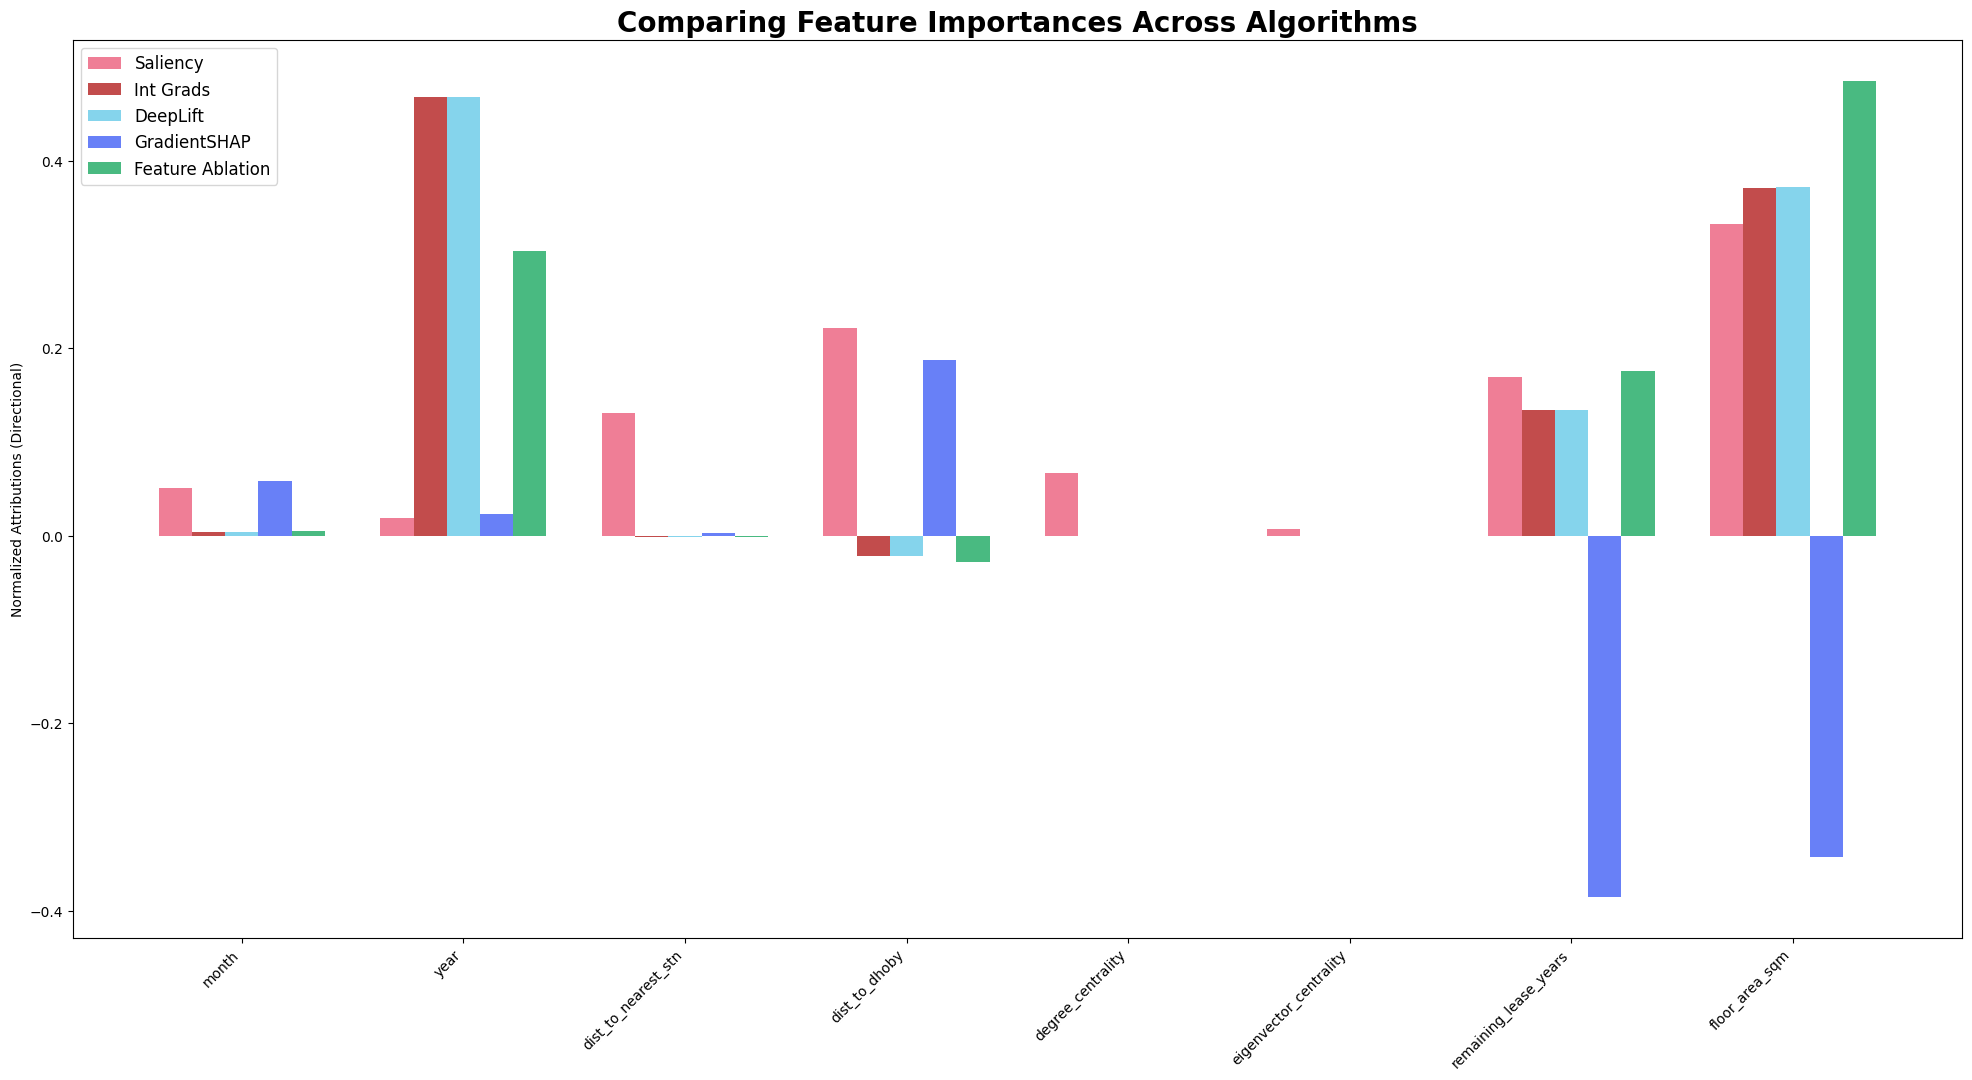

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Sum across the test set (axis=0) and detach from PyTorch
# Using the variables we created in the previous step
saliency_sum  = saliency_attr.detach().cpu().numpy().sum(axis=0)
ig_sum        = ig_attr.detach().cpu().numpy().sum(axis=0)
dl_sum        = deeplift_attr.detach().cpu().numpy().sum(axis=0)
gs_sum        = grad_shap_attr.detach().cpu().numpy().sum(axis=0)
fa_sum        = ablation_attr.detach().cpu().numpy().sum(axis=0)

# 2. Normalize using L1 norm so all algorithms are on the same visual scale
saliency_norm = saliency_sum / np.linalg.norm(saliency_sum, ord=1)
ig_norm       = ig_sum / np.linalg.norm(ig_sum, ord=1)
dl_norm       = dl_sum / np.linalg.norm(dl_sum, ord=1)
gs_norm       = gs_sum / np.linalg.norm(gs_sum, ord=1)
fa_norm       = fa_sum / np.linalg.norm(fa_sum, ord=1)

# 3. Plot Configuration
x_axis_data = np.arange(len(feature_cols))
width = 0.15
legends = ['Saliency', 'Int Grads', 'DeepLift', 'GradientSHAP', 'Feature Ablation']

plt.figure(figsize=(20, 10))
ax = plt.subplot()
ax.set_title('Comparing Feature Importances Across Algorithms', fontsize=20, fontweight='bold')
ax.set_ylabel('Normalized Attributions (Directional)')

# Styling
FONT_SIZE = 16
plt.rc('font', size=FONT_SIZE)            
plt.rc('axes', titlesize=FONT_SIZE)       
plt.rc('axes', labelsize=FONT_SIZE)       
plt.rc('legend', fontsize=FONT_SIZE - 4)  

# 4. Draw the Grouped Bars
ax.bar(x_axis_data,               saliency_norm, width, align='center', alpha=0.8, color='#eb5e7c')
ax.bar(x_axis_data + width,       ig_norm,       width, align='center', alpha=0.7, color='#A90000')
ax.bar(x_axis_data + 2 * width,   dl_norm,       width, align='center', alpha=0.6, color='#34b8e0')
ax.bar(x_axis_data + 3 * width,   gs_norm,       width, align='center', alpha=0.8, color='#4260f5')
ax.bar(x_axis_data + 4 * width,   fa_norm,       width, align='center', alpha=1.0, color='#49ba81')

ax.autoscale_view()
plt.tight_layout()

# 5. Format X-axis Ticks
# Shift the ticks to the center of the 5 bars (2 * width)
ax.set_xticks(x_axis_data + 2 * width)
ax.set_xticklabels(feature_cols, rotation=45, ha='right') 

# Place legend in a good spot automatically
plt.legend(legends, loc='best') 
plt.show()

We notice that `year`, `distance to dhoby`, `remaining_lease_year`, and `floor_area_sqm` are the most important features for prediction.

Graph for Integrated Gradients and DeepLift are almost identical, which is a good sanity check as DL is designed to be a faster version of IG

GradSHAP seems like the anamoly here as it uses a different baseline than IG and DL. IG and DL uses a hypothetical zero baseline (i.e. floor area, dist to dhoby, etc all = 0). Thats why compared to 0 floor area, a larger area will of course push up the resale price; and compared to 0 distance to dhoby (i.e. staying at Istana), staying further away from dhoby will lead to lower resale price.

GradSHAP uses a distribution of sample train data as baseline. If the 5000 test samples plotted happen to be slightly smaller or have less lease remaining than the average flat in training data (which both sound logically correct), GradientSHAP will correctly say: "Compared to the average train flat, the size of these test flats is actually pulling the predicted price down."

---

## 3. Model with Scaled Features

> Train a separate model with the same configuration but now standardise the features via **StandardScaler** (fit to training set, then transform all). State your observations with respect to GradientShap and explain why it has occurred.
(Hint: Many gradient-based approaches depend on a baseline, which is an important choice to be made. Check the default baseline settings carefully.)


In [16]:
# Standardize features using training split statistics only
feature_scaler = StandardScaler()
feature_scaler.fit(train[feature_cols])

train_scaled = train.copy()
val_scaled = val.copy()
test_scaled = test.copy()

train_scaled[feature_cols] = feature_scaler.transform(train[feature_cols])
val_scaled[feature_cols] = feature_scaler.transform(val[feature_cols])
test_scaled[feature_cols] = feature_scaler.transform(test[feature_cols])

In [17]:
train.head()

,month,year,dist_to_nearest_stn,dist_to_dhoby,degree_centrality,eigenvector_centrality,remaining_lease_years,floor_area_sqm,resale_price
0,1,2017,1.007264,7.006044,0.016807,0.006243,61.333333,44.0,232000.0
1,1,2017,1.271389,7.983837,0.016807,0.006243,60.583333,67.0,250000.0
2,1,2017,1.069743,9.090700,0.016807,0.002459,62.416667,67.0,262000.0
3,1,2017,0.946890,7.519889,0.016807,0.006243,62.083333,68.0,265000.0
4,1,2017,1.092551,9.130489,0.016807,0.002459,62.416667,67.0,265000.0


In [19]:
train_scaled.head()

,month,year,dist_to_nearest_stn,dist_to_dhoby,degree_centrality,eigenvector_centrality,remaining_lease_years,floor_area_sqm,resale_price
0,-1.770047,-1.263486,0.443573,-0.995640,-0.144385,-0.026607,-1.059473,-2.214319,232000.0
1,-1.770047,-1.263486,1.013476,-0.765013,-0.144385,-0.026607,-1.119636,-1.266950,250000.0
2,-1.770047,-1.263486,0.578384,-0.503942,-0.144385,-0.205230,-0.972570,-1.266950,262000.0
3,-1.770047,-1.263486,0.313303,-0.874442,-0.144385,-0.026607,-0.999309,-1.225760,265000.0
4,-1.770047,-1.263486,0.627598,-0.494557,-0.144385,-0.205230,-0.972570,-1.266950,265000.0


In [ ]:
# Same model configuration as before
data_config_scaled = DataConfig(
    target                          = [target_col],
    continuous_cols                 = feature_cols,
    normalize_continuous_features   = False,            # Or setting it to True and we can skip all the manual scaling above
)

tabular_model_scaled = TabularModel(
    data_config         = data_config_scaled,
    model_config        = model_config,
    optimizer_config    = optimizer_config,
    trainer_config      = trainer_config,
)

# Train scaled model
target_scaler_scaled = StandardScaler()
tabular_model_scaled.fit(
    train               = train_scaled,
    validation          = val_scaled,
    target_transform    = target_scaler_scaled
)

# Evaluate on scaled test set
test_predictions_scaled = tabular_model_scaled.predict(test_scaled)
pred_col_scaled = [c for c in test_predictions_scaled.columns if c.endswith("_prediction")][0]

y_true_scaled = test_scaled[target_col].to_numpy()
y_pred_scaled = test_predictions_scaled[pred_col_scaled].to_numpy()

test_mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
test_r2_scaled = r2_score(y_true_scaled, y_pred_scaled)

print(f"Scaled model Test MSE: {test_mse_scaled:.4f}")
print(f"Scaled model Test R2 : {test_r2_scaled:.4f}")

2026-03-05 23:42:19,751 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-03-05 23:42:19,758 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-03-05 23:42:19,762 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
2026-03-05 23:42:19,768 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: CategoryEmbeddingModel
2026-03-05 23:42:19,777 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-03-05 23:42:19,788 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/si

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ CategoryEmbeddingBackbone │    105 │ train │     0 │
│ 1 │ _embedding_layer │ Embedding1dLayer          │     16 │ train │     0 │
│ 2 │ head             │ LinearHead                │      6 │ train │     0 │
│ 3 │ loss             │ MSELoss                   │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 127                                                                                              
Non-trainable params: 0                                                                                            
Total params: 127                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: 
UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)

/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_conne
ctor.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

2026-03-05 23:43:01,464 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-03-05 23:43:01,464 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


Scaled model Test MSE: 8998225663.8050
Scaled model Test R2 : 0.6598


/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/opt/miniconda3/envs/sc4001-assignment/lib/python3.12/site-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


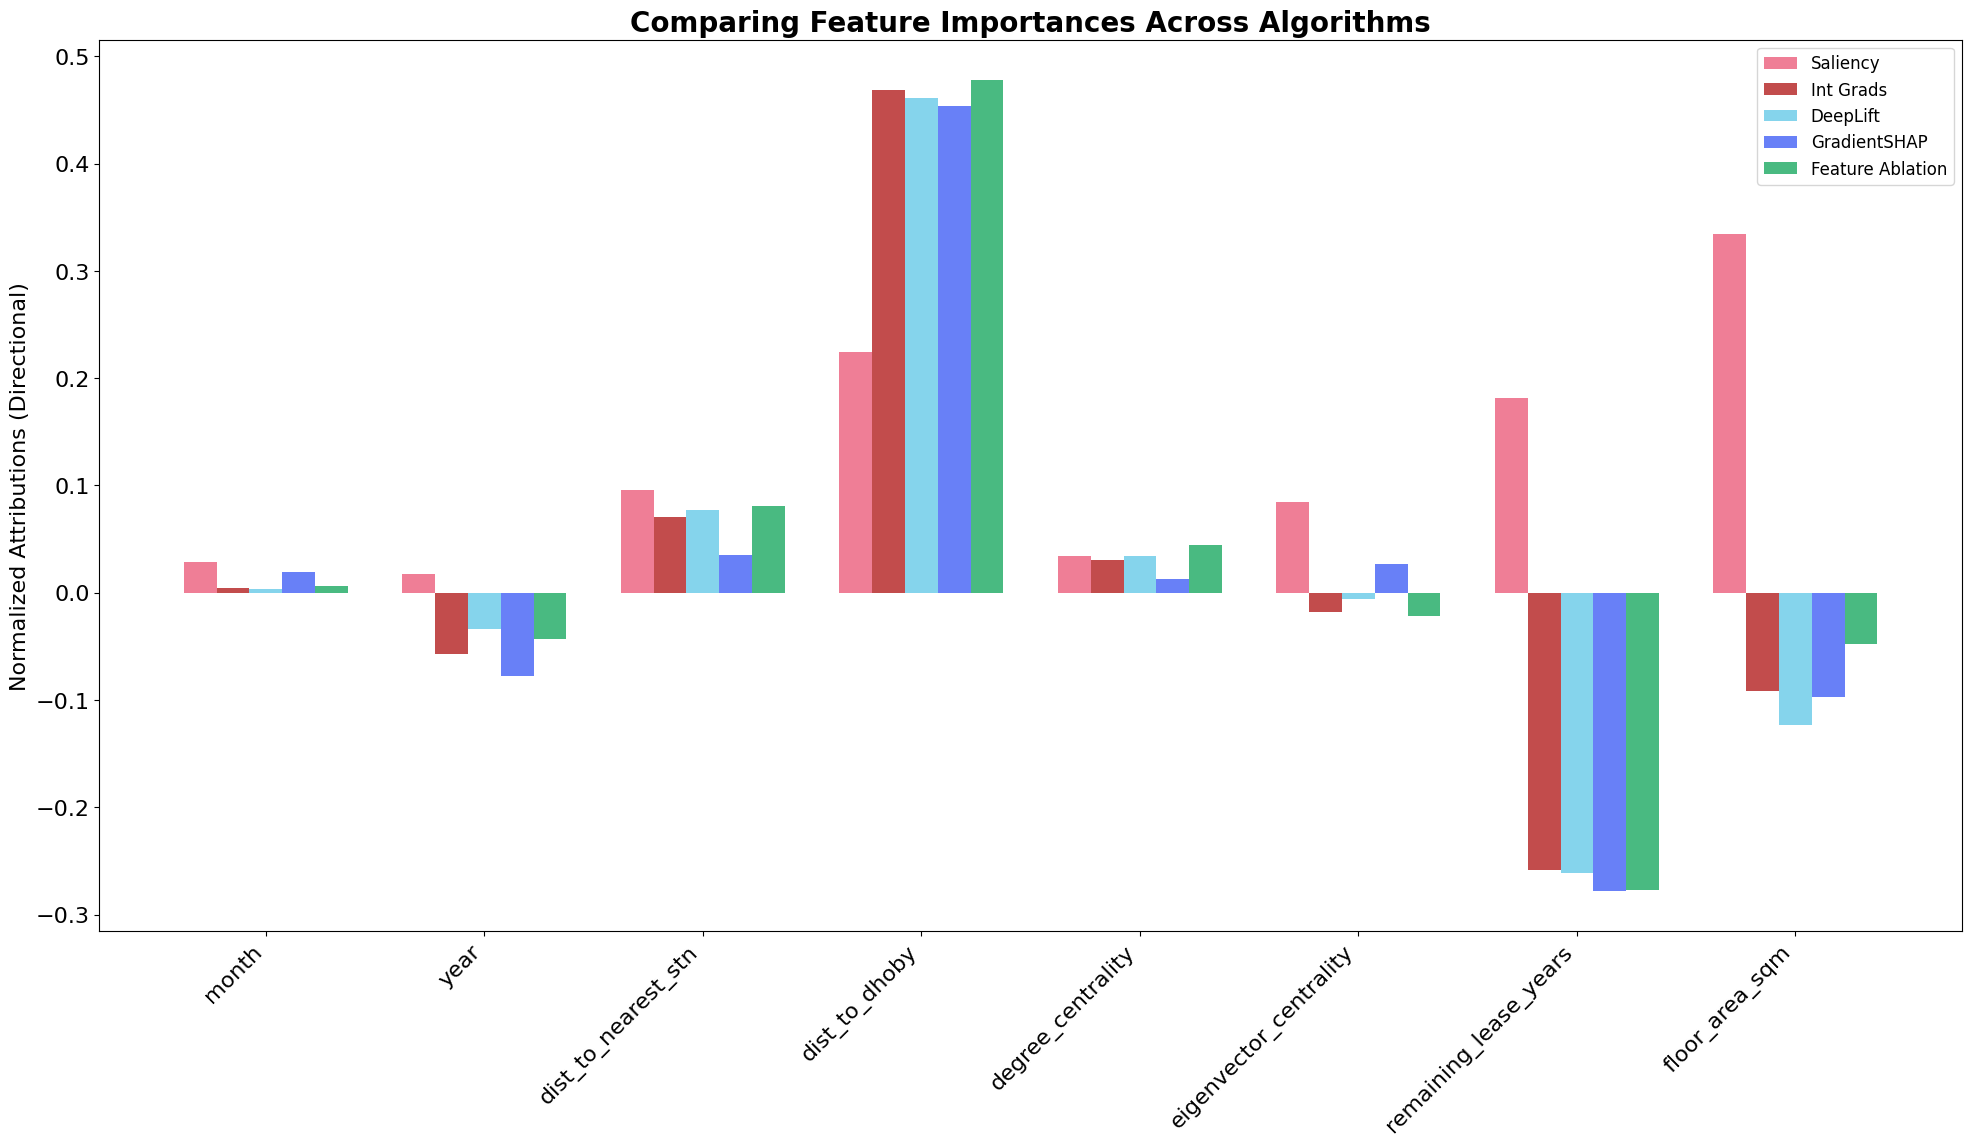

In [21]:
import torch
import torch.nn as nn

# Extract the raw PyTorch model from TabularModel
raw_model_scaled = tabular_model_scaled.model
raw_model_scaled.eval() # Set to evaluation mode

# Instantiate the wrapped model
wrapped_model_scaled = CaptumWrapper(raw_model_scaled)

# Grab the first 5000 rows of test set for faster processing
test_scaled_features_df = test_scaled[feature_cols].head (5000)
train_scaled_features_df = train_scaled[feature_cols].head (5000)

# Convert to PyTorch Tensor
X_test_scaled_tensor = torch.tensor(test_scaled_features_df.values, dtype=torch.float32)
X_train_scaled_tensor = torch.tensor(train_scaled_features_df.values, dtype=torch.float32)

# 1. Saliency
saliency = Saliency(wrapped_model_scaled)
saliency_attr = saliency.attribute(X_test_scaled_tensor)

# 2. Integrated Gradients
ig = IntegratedGradients(wrapped_model_scaled)
ig_attr = ig.attribute(X_test_scaled_tensor)               # baseline defaults to zero tensor if not provided

# 3. DeepLift
deeplift = DeepLift(wrapped_model_scaled)
deeplift_attr = deeplift.attribute(X_test_scaled_tensor)   # baseline defaults to zero tensor if not provided

# 4. GradientSHAP
grad_shap = GradientShap(wrapped_model_scaled)
grad_shap_attr = grad_shap.attribute(X_test_scaled_tensor, baselines=X_train_scaled_tensor)  # GradientSHAP usually expects a distribution of baselines, so we can pass the whole X_train_scaled_tensor as the training baseline reference

# 5. Feature Ablation
ablation = FeatureAblation(wrapped_model_scaled)
ablation_attr = ablation.attribute(X_test_scaled_tensor)   # baseline defaults to zero tensor if not provided


# 1. Sum across the test set (axis=0) and detach from PyTorch
# Using the variables we created in the previous step
saliency_sum  = saliency_attr.detach().cpu().numpy().sum(axis=0)
ig_sum        = ig_attr.detach().cpu().numpy().sum(axis=0)
dl_sum        = deeplift_attr.detach().cpu().numpy().sum(axis=0)
gs_sum        = grad_shap_attr.detach().cpu().numpy().sum(axis=0)
fa_sum        = ablation_attr.detach().cpu().numpy().sum(axis=0)

# 2. Normalize using L1 norm so all algorithms are on the same visual scale
saliency_norm = saliency_sum / np.linalg.norm(saliency_sum, ord=1)
ig_norm       = ig_sum / np.linalg.norm(ig_sum, ord=1)
dl_norm       = dl_sum / np.linalg.norm(dl_sum, ord=1)
gs_norm       = gs_sum / np.linalg.norm(gs_sum, ord=1)
fa_norm       = fa_sum / np.linalg.norm(fa_sum, ord=1)

# 3. Plot Configuration
x_axis_data = np.arange(len(feature_cols))
width = 0.15
legends = ['Saliency', 'Int Grads', 'DeepLift', 'GradientSHAP', 'Feature Ablation']

plt.figure(figsize=(20, 10))
ax = plt.subplot()
ax.set_title('Comparing Feature Importances Across Algorithms', fontsize=20, fontweight='bold')
ax.set_ylabel('Normalized Attributions (Directional)')

# Styling
FONT_SIZE = 16
plt.rc('font', size=FONT_SIZE)            
plt.rc('axes', titlesize=FONT_SIZE)       
plt.rc('axes', labelsize=FONT_SIZE)       
plt.rc('legend', fontsize=FONT_SIZE - 4)  

# 4. Draw the Grouped Bars
ax.bar(x_axis_data,               saliency_norm, width, align='center', alpha=0.8, color='#eb5e7c')
ax.bar(x_axis_data + width,       ig_norm,       width, align='center', alpha=0.7, color='#A90000')
ax.bar(x_axis_data + 2 * width,   dl_norm,       width, align='center', alpha=0.6, color='#34b8e0')
ax.bar(x_axis_data + 3 * width,   gs_norm,       width, align='center', alpha=0.8, color='#4260f5')
ax.bar(x_axis_data + 4 * width,   fa_norm,       width, align='center', alpha=1.0, color='#49ba81')

ax.autoscale_view()
plt.tight_layout()

# 5. Format X-axis Ticks
# Shift the ticks to the center of the 5 bars (2 * width)
ax.set_xticks(x_axis_data + 2 * width)
ax.set_xticklabels(feature_cols, rotation=45, ha='right') 

# Place legend in a good spot automatically
plt.legend(legends, loc='best') 
plt.show()

With scaled features, the important features are now `dist to dhoby`, `remaining lease year` and `floor_area_sqm`. `year` is no longer an important feature as without scaling, the year 2017 seems like a huge jump compared to year 0 (for IG and DL), while in fact the HDB are not 2017 years newer.

Now all 4 main algorithms (beside Saliency) almost aligns with one another, as standard scaler ensures the zero tensor to represent the average HDB for IG and DL, which is comparable with the baseline used for GradientSHAP.

`dist_to_dhoby` is positive, it means this batch of test flats was likely closer to the city than the average train flats, pushing their predicted price up.

`remaining_lease_years` and `floor_area_sqm` is showing large negative bars, meaining that for this batch of test flats, they have shorter lease and smaller floor area compared to the average train flats, pulling the predicted price down.

> Read https://distill.pub/2020/attribution-baselines/ to build up your understanding of Integrated Gradients (IG). Reading the sections before the section on ‘Game Theory and Missingness’ will be sufficient. Keep in mind that this article mainly focuses on classification problems. You might find the following [descriptions](https://captum.ai/docs/attribution_algorithms) and [comparisons](https://captum.ai/docs/algorithms_comparison_matrix) in Captum useful as well.


> Then, identify the algorithms that produced similar results, if any, and explain why in the context of our dataset. If no methods appear similar, discuss possible reasons for the differences


The algo thats most similiar to IG is DL. 

Because both of them essentially compares the current input to a reference baseline (zero tensor in this case), they see very similar results. IG computes an integral over a continuous path from a baseline to the input, DL computes the discrete difference between the input's activation and a reference (baseline) activation, so DL is a faster, discrete approximation of IG.

Since the fundemental principle of IG and DL are "is a feature important relative to a baseline" (instead of simply "is the feature important"), the choice of baseline is very important.

Before feature scaling, a baseline of zero tensor means a HDB build in year 0 (when jesus was born), 0 sqm, 0 lease year remaining, and 0 distance to dhoby. Thus, the scale of the values for each feature heavily determinates the normalized attribution. For example, a big leap from year 0 to year 2017 will cause a large increase in attribution.

After feature scaling, a baseline of zero tensor means an average HDB in Singapore. So now, IG, DL, and GradientSHAP are all comparing the importance of a feature to the average HDB in Singapore, so with same reference, they see similar results.

Feature Ablation sets a feature to its baseline and checks the drop in prediction. Since the baseline is now the "average flat", ablating a feature means asking: "What happens to the price if we replace this flat's specific size with the average size?. This aligns with what IG, DL, and GradientSHAP are measuring.

Lastly, Saliency is the odd one out as it is the only algorithm here that does not use a baseline. It simply computes the local gradient (derivative) at the exact specific data point (using a small delta). So it suffers from saturation and lack of completeness (prone to noises)